In [2]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmxvCN2R2C
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

## Demo Notebook 04 - DarkGreyFit

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`, setting up and evaluating multiple pipelines at once.


Our temporal resolution is 1 hour

In [46]:
# the duration of a record (in seconds - 5 minutes)
rec_duration = 5/60

Read some demo data.  
* Ph: Heating system power output
* Ta: Ambient temperature
* Ti: Internal temperature

We are also setting a set of custom fields in our input data: `Ti0`, `Th0` and `Te0`. These fields define the initial conditions for `Ti`, `Th` and `Te` for each record of the input data respectively. E.g. if a sub-model is trained based on the 10-20 records of the training data, the initial conditions for the above params will be set by the 10. record of the input data. 

Note: This demo data is intentionally far from ideal and particularly challenging to model with low errors. It is taken from a building where there are many factors influencing the heat dynamics of the building that are not accounted for in the modelling (solar gains, passive gains, hot water demand, gas use in the canteen etc.). The time period is relatively short to maintain a reasonable solution time for the demo. However, it includes an also challenging holiday period when the heating system is shut down.

In [47]:
input_df = pd.read_csv('./data/general_data_csv.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['Q'] = input_df['R01_06_FCI01']
input_df['MVV'] = input_df['R01_06_MVV01']
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Gk'] = input_df['HTR9_VES01_SI01']
input_df['svent'] = input_df['HTR9_VEN02_Status']
input_df['Tfor'] = input_df['HTRK_RAD01_TR02']
input_df['C'] = input_df['R01_06_CO201']

A_w = 10    # m²
g = 0.35    # total solar energy transmittance of the glazing 
S = 20      # m²
V0 = 2.5*S   # m³
E0 = 0.016   # m³/h
C_out0 = 400 # ppm

# Compute derived columns
input_df['N'] = input_df['Q'] / E0 * (input_df['C'] - C_out0) / 10**6
input_df['Q_vent'] = input_df['svent'] * 1.2 * 1000 * input_df['Q'] * (20 - input_df['Ti']) / 3600
input_df['Q_solar'] = g * A_w * input_df['Gk']
input_df['ACH'] = input_df['Q'] / V0

# Set initial conditions
input_df['Ti0'] = input_df['Ti']
input_df['Th0'] = input_df['Ti']
input_df['xv0'] = input_df['MVV'] / 100
input_df['C0'] = input_df['C']
input_df['N0'] = input_df['N']

input_X = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (4032, 11), input y shape: (4032,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (3225, 11), y shape: (3225,)
Test: X shape: (807, 11), y shape: (807,)


Set up the model training parameters for each model instance that we want to spin up in the pipeline.  

The `Ti0` param is the initial condition for the internal temperature at t=0 - this is set to the first record of `X_train['Ti0']` as described above and is fixed, hence `vary: False`.  

The `Te0` param is the initial condition for the building envelope temperature at t=0 - - this is set to the first record of `X_train['Te0']` as described above and is NOT fixed, hence `vary: True`.  

The `Th0` param is the initial condition for the heating system temperature at t=0 - - this is set to the first record of `X_train['Th0']` as described above and is NOT fixed, hence `vary: True`.  

`Ci`, `Ce`, `Rie` and `Ria` params are the initial conditions for these thermal parameters. As these will be fit by the model training their default is `vary: True`. The values for these params' initial conditions are set arbitrarily to `1` it is assumed that no estimates have been calculated for them (e.g. based on building physical properties).

Note that we've added the `Ch` and `Rih` params with set initial conditions not allowed to vary. These are the RC params for the heating system and their values have been precalculated from the heating system's time constant to make this example simpler.


In [49]:
S = 20      # m²
V0 = 2.5*S   # m³
E0 = 0.016   # m³/h
C_out0 = 400 # ppm

train_params_TiTmxvCN2R2C = {
    'Ti0': {'value': X_train.iloc[0]['Ti0'], 'vary': False},
    'Th0': {'value': X_train.iloc[0]['Th0'], 'vary': True, 'min': 5, 'max': 35},
    'xv0': {'value': X_train.iloc[0]['xv0'], 'vary': False},
    'C0': {'value': X_train.iloc[0]['C0'], 'vary': False},
    'N0': {'value': X_train.iloc[0]['N0'], 'vary': False},
    
    'Ci': {'value': 50000, 'vary': True, 'min': 10000, 'max': 500000},
    'Ch': {'value': 150000, 'vary': True, 'min': 10000, 'max': 500000},
    'Rint': {'value': 0.05, 'vary': True, 'min': 0.001, 'max': 1},
    'Rout': {'value': 0.1, 'vary': True, 'min': 0.001, 'max': 2},
    'alpha': {'value': 1500/S, 'vary': False},
    'tau_v': {'value': 0.083, 'vary': True, 'min': 0.025, 'max': 0.25}, # in h (0.083h = 300s)
    'q_pers': {'value': 75, 'vary': False},
    'q_equip_var': {'value': 80, 'vary': False},
    'V': {'value': V0, 'vary': False},
    'E': {'value': E0, 'vary': False},
    'C_out': {'value': C_out0, 'vary': False},

    'Q_int_const': {'value': 10 * S, 'vary': False}
}

Set up our initial conditions parameters map for testing

In [50]:
ic_params_map = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    #'Tm0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: X_test.iloc[0]['N0']
}

We can instantiate a range of models to be evaluated - in this case we are setting up 5 different models starting from the simplest `Ti` to `TiTeThRia` with medium complexity.


In [51]:
models = [TiTmxvCN2R2C(train_params_TiTmxvCN2R2C, rec_duration)]

We need to split our training data set into managable chunks for the prefit stage. `Sklearn` is quite helpful here again, in case we wanted to define the prefit sets to be 1 day (24 hours) long:

In [52]:
prefit_splits = KFold(n_splits=int(len(X_train) / 24), shuffle=False).split(X_train)

To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`:

In [53]:
error_metric = rmse

We can define a prefit "survival threshold" to trim the number of model fits during the training process. Any models achieving a higher error during the prefit stage will not make it into the training stage.

In [54]:
prefit_filter = lambda error: abs(error) < 2

Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well, and while the standard Nelder-Mead and Levenberg-Marquardt methods work well in general, it is worth experimenting with others (see here for a list of supported methods: https://lmfit.github.io/lmfit-py/fitting.html#fit-methods-table).

In [55]:
method = 'nelder'

Setting up is ready! We only need to call the `darkgreyfit` convenience pipeline function that delegates the work to the prefit, train and test low-level procedures running on multiple processes and reducing / cleaning the interim results. The returned `pandas.DataFrame` contains the fit models and their train/test performance evaluation.   


In [56]:
#df = darkgreyfit(models, X_train, y_train, X_test, y_test, ic_params_map, error_metric,
                 #prefit_splits=prefit_splits, prefit_filter=prefit_filter, reduce_train_results=True, 
                 #method=method, n_jobs=-1, verbose=10)

df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)



2026-01-15 21:53:18,089 darkgreybox  INFO     Training models...
2026-01-15 21:53:32,923 darkgreybox  INFO     Generating predictions for 1 models...


In this specific example:
* *Initial Population:* 5 model structures were prefit to 28x 24-hour data chunks resulting in 140 pipelines
* *Fitness Function:* The RMSE of a prefit had to be < 2˚C to survive
* *Selection:* 110 pipelines survived the prefit selection and made it into training on the entire training set 
* (No *Crossover* or *Mutation*)
* *Termination:* Out of the 110 pipelines trained, 11 distinct model results were found (i.e. many pipelines were arriving at the same parameter set results)

In [57]:
df

train                            \
                 start_date                  end_date   
0 2025-08-31 22:00:00+00:00 2025-09-12 02:40:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                         \
                                        model_result       time  method   
0  DarkGreyModelResult(Z=array([26.2       , 26.1...  14.827645  nelder   

                                 test                            \
      error                start_date                  end_date   
0  0.565458 2025-09-12 02:45:00+00:00 2025-09-14 21:55:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                          
                                        model_result      time     error  
0  DarkGreyModelResult(Z=array([23.9       , 23.8...  0.008568  0.431335

We can select the model with the lowest error and display its params

In [58]:
select_idx = df[('train', 'error')].argmin()

model = df.loc[select_idx, ('train', 'model')]
train_results = df.loc[select_idx, ('train', 'model_result')]
test_results = df.loc[select_idx, ('test', 'model_result')]

model.result.params

name,value,initial value,min,max,vary
Ti0,23.9000000,26.2,-inf,inf,False
Th0,24.2234677,26.2,5.00000000,35.0000000,True
xv0,0.00000000,0.0,-inf,inf,False
C0,423.260606,418.0,-inf,inf,False
N0,0.00000000,0.13025659095,-inf,inf,False
Ci,10000.0028,50000.0,10000.0000,500000.000,True
Ch,160853.591,150000.0,10000.0000,500000.000,True
Rint,0.00189676,0.05,1.0000e-03,1.00000000,True
Rout,0.01634529,0.1,1.0000e-03,2.00000000,True
alpha,75.0000000,75.0,-inf,inf,False


The results show that the `TiTeThRia` model has a good fit on the training set (R2=0.9612) and the errors are low for both the training and test sets (RMSE 0.3719 and 0.3383 respectively) indicating that the model generalises well for data it hasn't seen before (no overfitting problem).

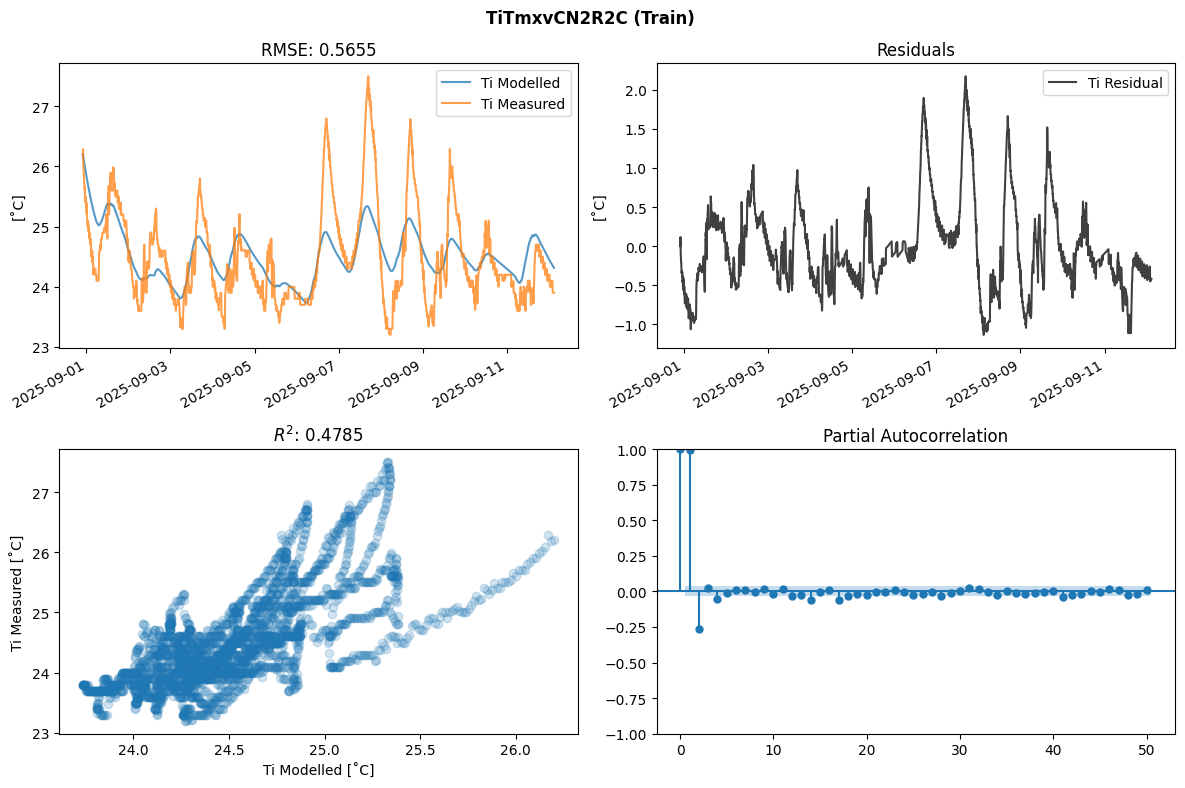

In [59]:
plot(y_train, train_results, 'TiTmxvCN2R2C (Train)')

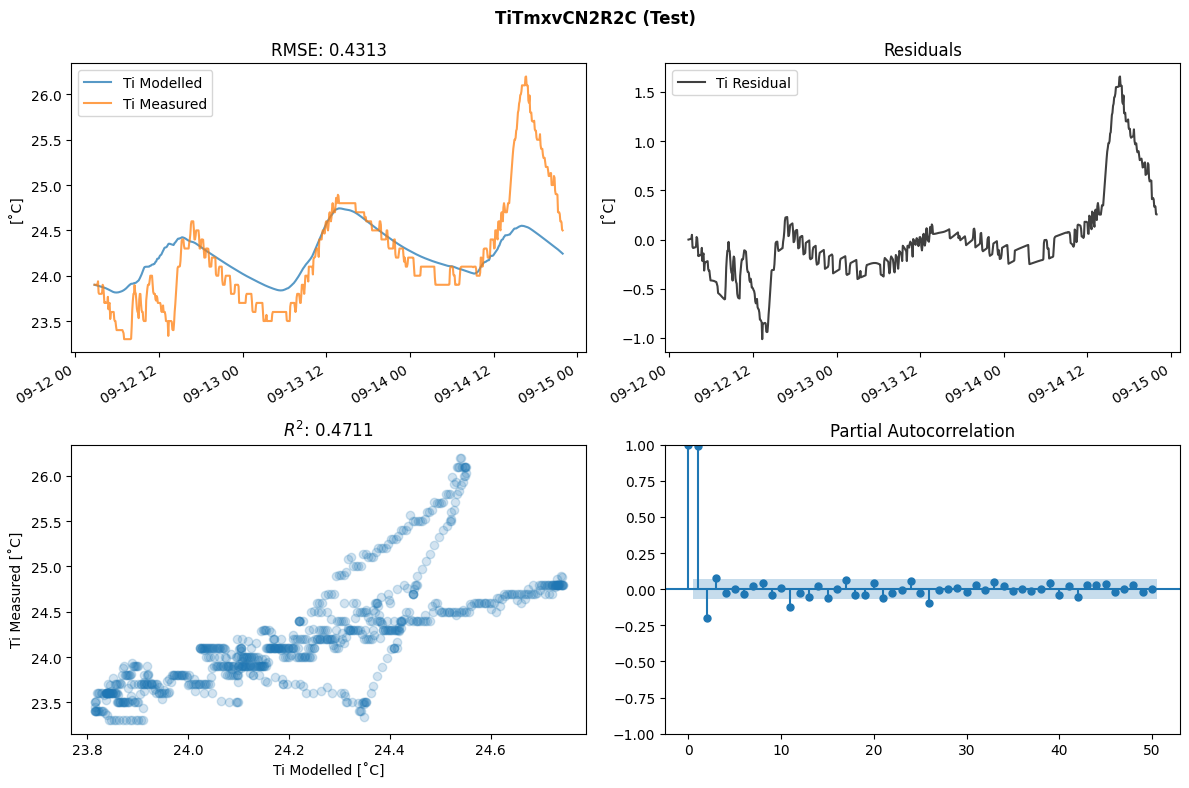

In [60]:
plot(y_test, test_results, 'TiTmxvCN2R2C (Test)')

In contrast, the `Ti` model has a poor fit on the training set (R2=0.79) which is clear from the temperature plots as well. Due to low model complexity there is a definite underfitting problem going in here, which of course also results in poor test set performance. This is hardly surprising, as the `Ti` model only keeps internal states of the internal temperatures (`Ti`) and it is unaware of the internal states of the heating system / building envelope temperatures  (`Th` and `Te` respectively) - both of which are important for describing the system components' thermal inertia.

## Using the Kalman Filter Model for Occupancy Estimation

The `TiTmxvCN2R2C_KF` model extends the base model with a Kalman filter that updates the occupancy estimate N at each timestep based on CO2 observations. This allows N to vary over time instead of staying constant.

In [83]:
# Reload the models module to get the new TiTmxvCN2R2C_KF class
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiTmxvCN2R2C_KF

# Add the CO2 observations to the input data for the Kalman filter
input_df['C_obs'] = input_df['C']  # Use measured CO2 as observations
input_df['P_N0'] = 1.0  # Initial variance of N estimate (constant for all rows)

# Update input_X to include C_obs and P_N0
input_X_kf = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]

# Split for KF model
X_train_kf, X_test_kf, _, _ = train_test_split(input_X_kf, input_y, test_size=0.2, shuffle=False)

# Add Kalman filter parameters to the training params
train_params_KF = train_params_TiTmxvCN2R2C.copy()
train_params_KF['Q_N'] = {'value': 0.5, 'vary': False}     # Process noise for N (persons²/h)
train_params_KF['R_C'] = {'value': 50.0, 'vary': False}    # Measurement noise for CO2 (ppm²)
train_params_KF['P_N0'] = {'value': 1.0, 'vary': False}    # Initial variance of N

print("Training parameters for Kalman Filter model:")
print(f"  Q_N (process noise): {train_params_KF['Q_N']['value']}")
print(f"  R_C (measurement noise): {train_params_KF['R_C']['value']}")

Training parameters for Kalman Filter model:
  Q_N (process noise): 0.5
  R_C (measurement noise): 50.0


In [84]:
# Create and fit the Kalman Filter model
models_kf = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

# Update ic_params_map for KF model
ic_params_map_kf = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: train_result.var['N'][-1],  # Use last estimated N
    'P_N0': lambda X_test, y_test, train_result: train_result.var['P_N'][-1],  # Use last variance
}

df_kf = darkgreyfit(
    models=models_kf,
    X_train=X_train_kf,
    y_train=y_train,
    X_test=X_test_kf,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Kalman Filter model training complete!")

2026-01-15 22:38:22,070 darkgreybox  INFO     Training models...
2026-01-15 22:38:52,992 darkgreybox  INFO     Generating predictions for 1 models...
Kalman Filter model training complete!


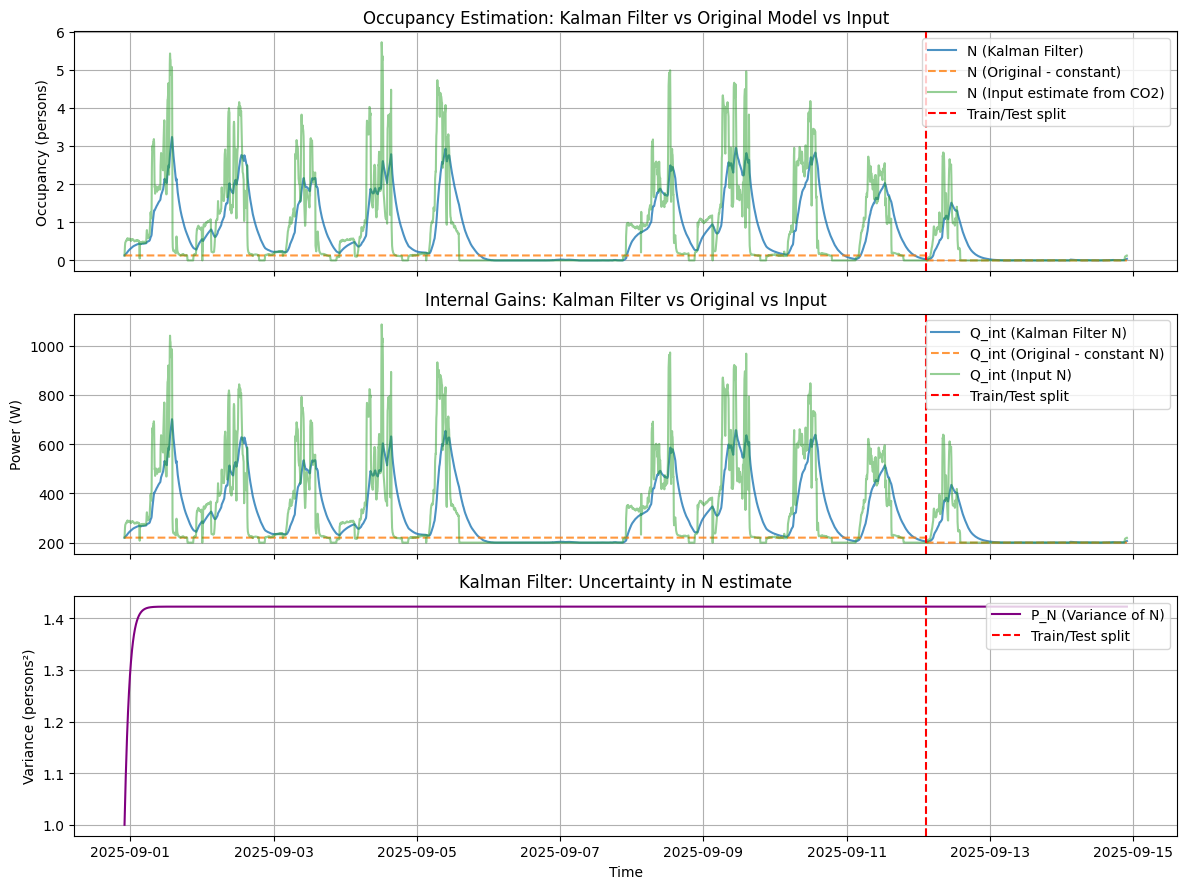


--- Model Comparison ---
Original Model - Train RMSE: 0.5655°C
Original Model - Test RMSE:  0.4313°C
Kalman Filter  - Train RMSE: 0.5693°C
Kalman Filter  - Test RMSE:  0.4600°C


In [85]:
# Extract results from Kalman Filter model
select_idx_kf = df_kf[('train', 'error')].argmin()
model_kf = df_kf.loc[select_idx_kf, ('train', 'model')]
train_results_kf = df_kf.loc[select_idx_kf, ('train', 'model_result')]
test_results_kf = df_kf.loc[select_idx_kf, ('test', 'model_result')]

# Compare N from original model vs Kalman Filter model
N_kf_train = train_results_kf.var['N']
N_kf_test = test_results_kf.var['N']
N_kf_full = np.concatenate([N_kf_train, N_kf_test])

# Plot comparison of N estimates
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

idx = input_y.index

# Plot 1: N comparison
axes[0].plot(idx, N_kf_full, label='N (Kalman Filter)', alpha=0.8)
axes[0].plot(idx, np.concatenate([N_train, N_test]), label='N (Original - constant)', linestyle='--', alpha=0.8)
axes[0].plot(input_df.loc[idx, 'N'], label='N (Input estimate from CO2)', alpha=0.5)
axes[0].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[0].set_ylabel('Occupancy (persons)')
axes[0].set_title('Occupancy Estimation: Kalman Filter vs Original Model vs Input')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Q_int comparison
Q_int_kf = Q_int_const + (q_pers + q_equip_var) * N_kf_full
axes[1].plot(idx, Q_int_kf, label='Q_int (Kalman Filter N)', alpha=0.8)
axes[1].plot(input_df.loc[idx, 'Q_int_model'], label='Q_int (Original - constant N)', linestyle='--', alpha=0.8)
axes[1].plot(input_df.loc[idx, 'Q_int_input'], label='Q_int (Input N)', alpha=0.5)
axes[1].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[1].set_ylabel('Power (W)')
axes[1].set_title('Internal Gains: Kalman Filter vs Original vs Input')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Variance of N (uncertainty)
P_N_train = train_results_kf.var['P_N']
P_N_test = test_results_kf.var['P_N']
P_N_full = np.concatenate([P_N_train, P_N_test])
axes[2].plot(idx, P_N_full, label='P_N (Variance of N)', color='purple')
axes[2].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[2].set_ylabel('Variance (persons²)')
axes[2].set_xlabel('Time')
axes[2].set_title('Kalman Filter: Uncertainty in N estimate')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print RMSE comparison
print(f"\n--- Model Comparison ---")
print(f"Original Model - Train RMSE: {df.loc[select_idx, ('train', 'error')]:.4f}°C")
print(f"Original Model - Test RMSE:  {df.loc[select_idx, ('test', 'error')]:.4f}°C")
print(f"Kalman Filter  - Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"Kalman Filter  - Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")

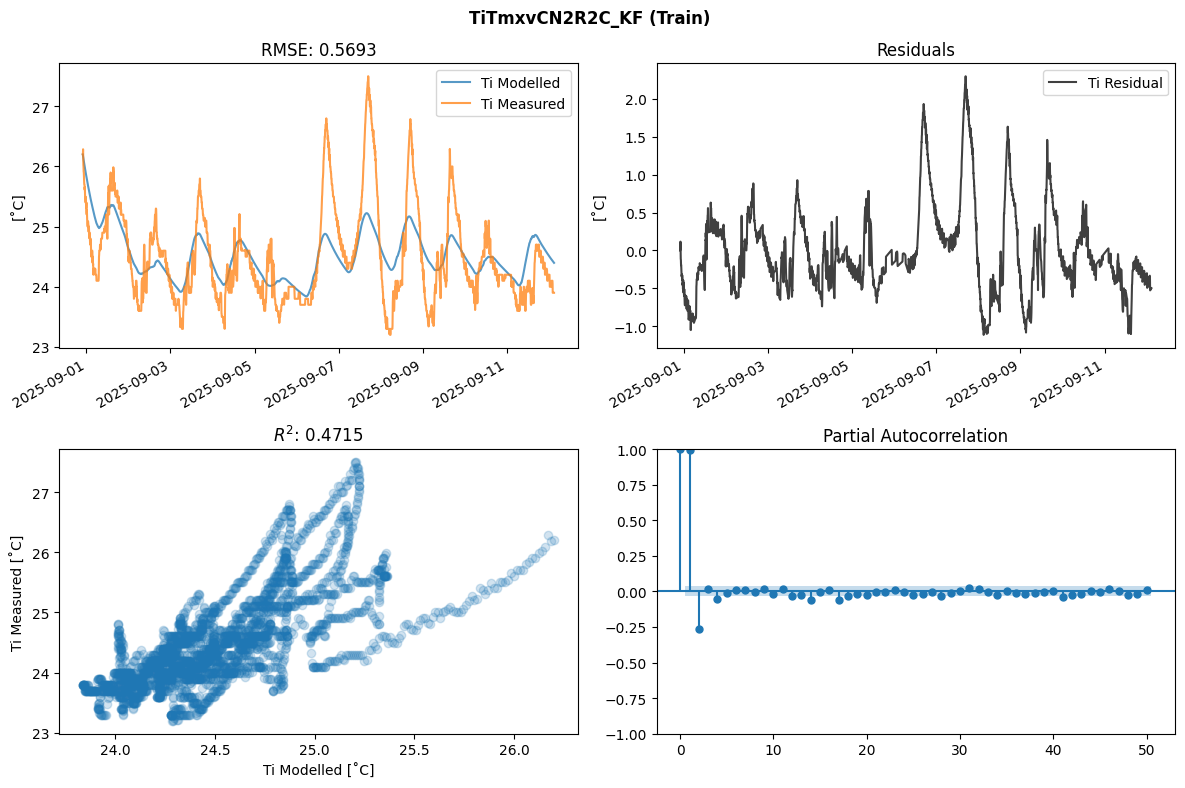

In [86]:
# Plot Train results for Kalman Filter model
plot(y_train, train_results_kf, 'TiTmxvCN2R2C_KF (Train)')

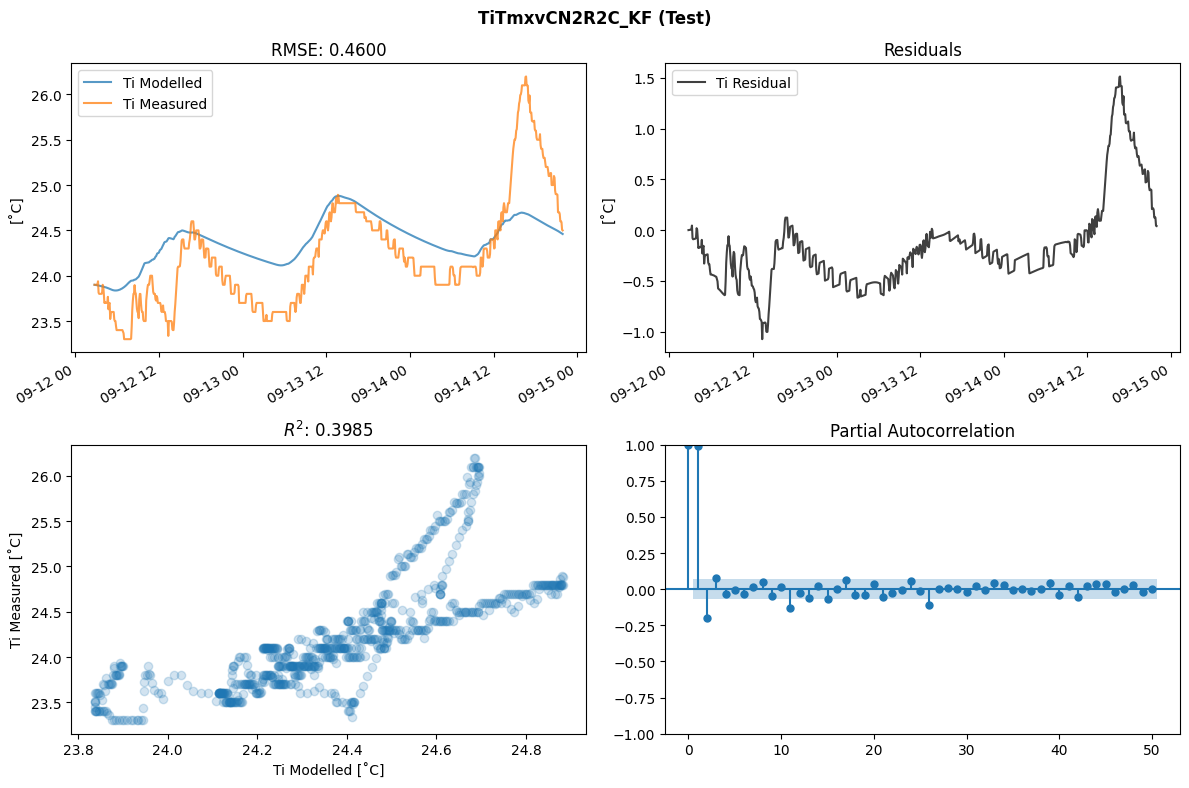

In [87]:
# Plot Test results for Kalman Filter model
plot(y_test, test_results_kf, 'TiTmxvCN2R2C_KF (Test)')

--- Period Analysis: 2025-09-07 to 2025-09-10 ---

Days of week in this period:
Sunday       288
Monday       288
Tuesday      288
Wednesday      1
Name: count, dtype: int64


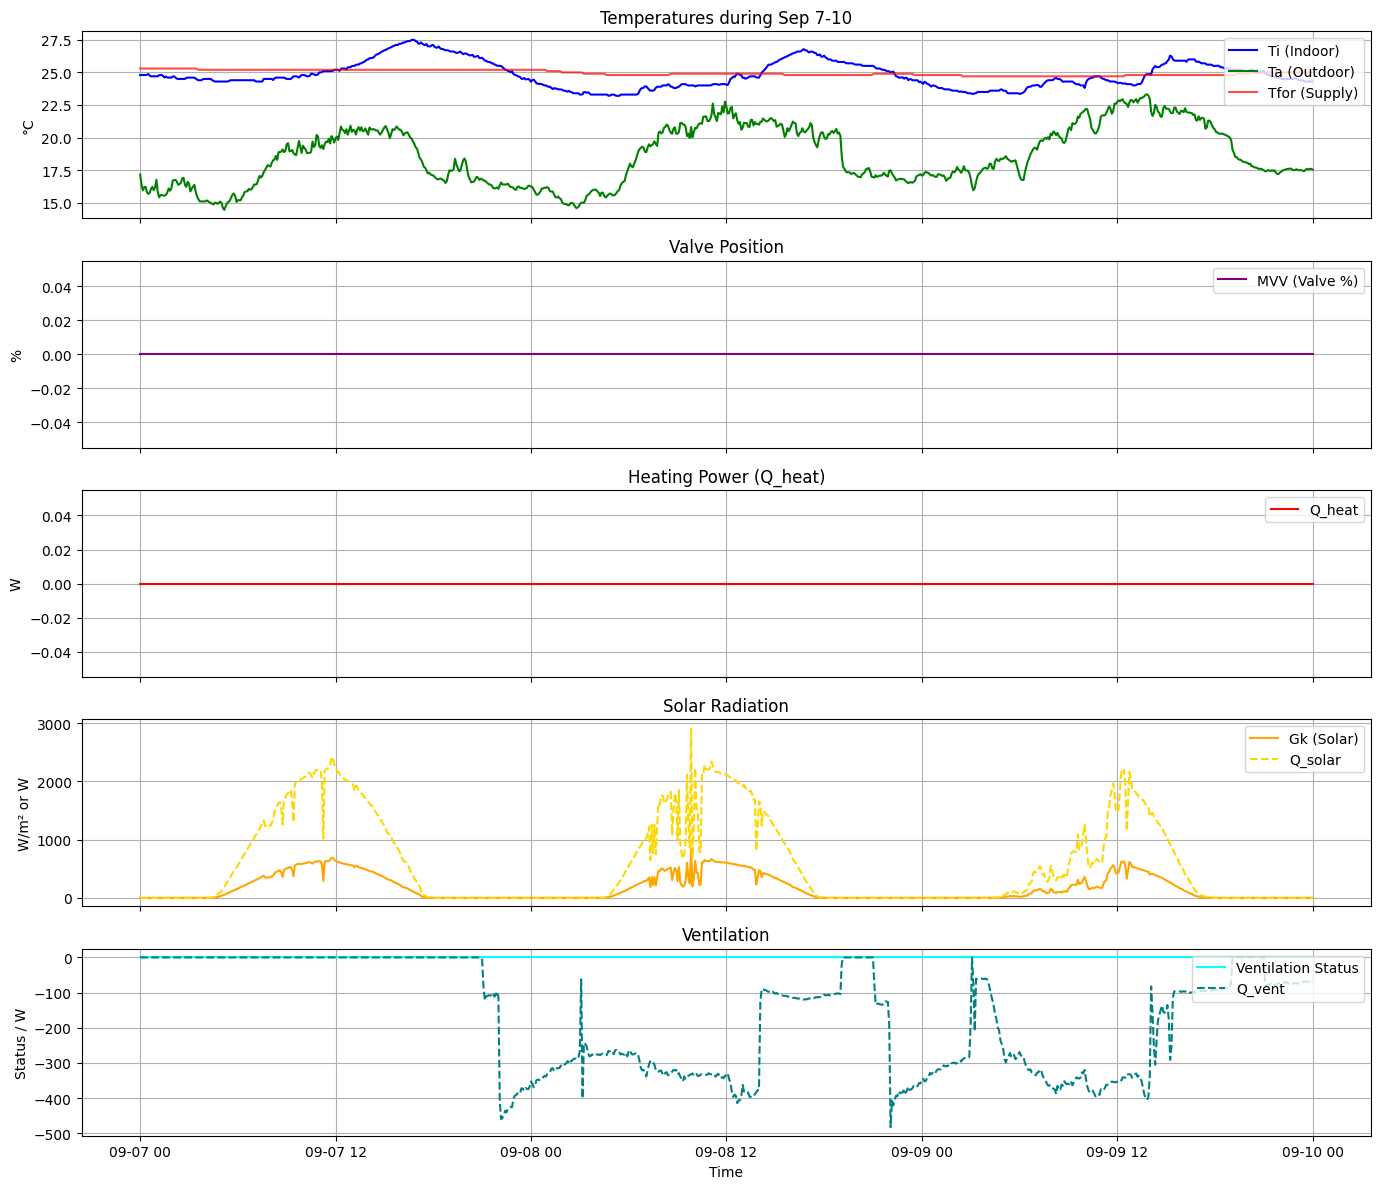


--- Statistics for Sep 7-10 ---
               Ti          Ta        Tfor    MVV          Gk  svent  \
count  865.000000  865.000000  865.000000  865.0  865.000000  865.0   
mean    24.817458   18.622098   24.964146    0.0  169.000747    1.0   
std      1.022141    2.251674    0.199969    0.0  216.080999    0.0   
min     23.200000   14.446000   24.700000    0.0    0.000000    1.0   
25%     24.078000   16.799000   24.800000    0.0    0.000000    1.0   
50%     24.600000   18.220000   24.900000    0.0   26.511040    1.0   
75%     25.500000   20.594841   25.200000    0.0  328.628752    1.0   
max     27.500000   23.316485   25.300000    0.0  834.879614    1.0   

                Q  
count  865.000000  
mean   118.166396  
std    113.970118  
min      0.000000  
25%      0.000000  
50%     53.178684  
75%    248.945455  
max    361.874248  


In [88]:
# Investigate the period Sep 7-10 with large Ti variations
period_start = '2025-09-07'
period_end = '2025-09-10'

# Check if it's a weekend
print(f"--- Period Analysis: {period_start} to {period_end} ---")
period_mask = (input_df.index >= period_start) & (input_df.index <= period_end)
period_data = input_df.loc[period_mask]

# Check day of week
print(f"\nDays of week in this period:")
print(period_data.index.day_name().value_counts())

# Plot key variables during this period
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# 1. Temperatures
axes[0].plot(period_data.index, period_data['Ti'], label='Ti (Indoor)', color='blue')
axes[0].plot(period_data.index, period_data['Ta'], label='Ta (Outdoor)', color='green')
axes[0].plot(period_data.index, period_data['Tfor'], label='Tfor (Supply)', color='red', alpha=0.7)
axes[0].set_ylabel('°C')
axes[0].set_title('Temperatures during Sep 7-10')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# 2. Valve position (MVV)
axes[1].plot(period_data.index, period_data['MVV'], label='MVV (Valve %)', color='purple')
axes[1].set_ylabel('%')
axes[1].set_title('Valve Position')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# 3. Q_heat (computed from model)
if 'Q_heat_model' in period_data.columns:
    axes[2].plot(period_data.index, period_data['Q_heat_model'], label='Q_heat', color='red')
axes[2].set_ylabel('W')
axes[2].set_title('Heating Power (Q_heat)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

# 4. Solar radiation
axes[3].plot(period_data.index, period_data['Gk'], label='Gk (Solar)', color='orange')
axes[3].plot(period_data.index, period_data['Q_solar'], label='Q_solar', color='gold', linestyle='--')
axes[3].set_ylabel('W/m² or W')
axes[3].set_title('Solar Radiation')
axes[3].legend(loc='upper right')
axes[3].grid(True)

# 5. Ventilation
axes[4].plot(period_data.index, period_data['svent'], label='Ventilation Status', color='cyan')
axes[4].plot(period_data.index, period_data['Q_vent'], label='Q_vent', color='teal', linestyle='--')
axes[4].set_ylabel('Status / W')
axes[4].set_xlabel('Time')
axes[4].set_title('Ventilation')
axes[4].legend(loc='upper right')
axes[4].grid(True)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n--- Statistics for Sep 7-10 ---")
print(period_data[['Ti', 'Ta', 'Tfor', 'MVV', 'Gk', 'svent', 'Q']].describe())

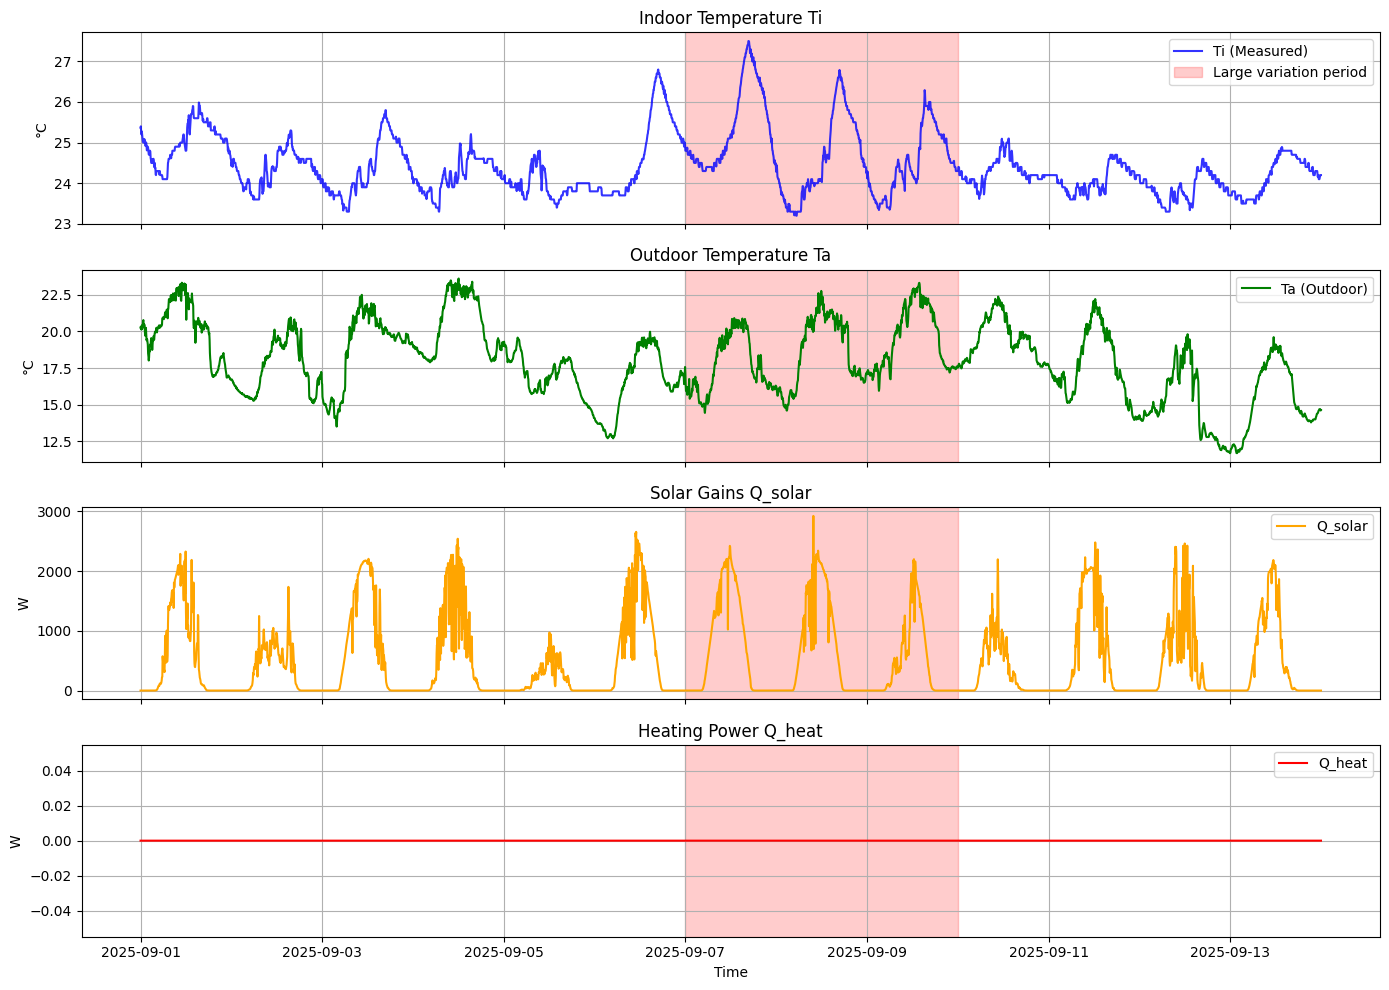


=== Comparing Sep 1-6 vs Sep 7-10 ===

--- Sep 1-6 (before large variations) ---
                Ti           Ta      Q_solar  Q_heat_model   svent  \
count  1728.000000  1728.000000  1728.000000        1728.0  1728.0   
mean     24.432950    18.404867   480.735951           0.0     1.0   
std       0.689004     2.499715   681.557597           0.0     0.0   
min      23.300000    12.706805     0.000000           0.0     1.0   
25%      23.900000    16.500000     0.000000           0.0     1.0   
50%      24.300000    18.400000    63.031772           0.0     1.0   
75%      24.835948    20.180000   748.484791           0.0     1.0   
max      26.800000    23.613333  2654.692356           0.0     1.0   

            Q_vent  
count  1728.000000  
mean   -177.029177  
std     160.857305  
min    -496.765276  
25%    -340.560828  
50%     -91.729562  
75%       0.000000  
max      -0.000000  

--- Sep 7-10 (large variations) ---
               Ti          Ta      Q_solar  Q_heat_model  sve

In [90]:
# Compare Sep 1-6 vs Sep 7-10 vs Sep 11-14 to find what's different
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Full period Sep 1-14
full_mask = (input_df.index >= '2025-09-01') & (input_df.index <= '2025-09-14')
full_data = input_df.loc[full_mask]

# 1. Ti - measured
axes[0].plot(full_data.index, full_data['Ti'], label='Ti (Measured)', color='blue', alpha=0.8)
axes[0].axvspan(pd.Timestamp('2025-09-07'), pd.Timestamp('2025-09-10'), alpha=0.2, color='red', label='Large variation period')
axes[0].set_ylabel('°C')
axes[0].set_title('Indoor Temperature Ti')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# 2. Outdoor temperature Ta
axes[1].plot(full_data.index, full_data['Ta'], label='Ta (Outdoor)', color='green')
axes[1].axvspan(pd.Timestamp('2025-09-07'), pd.Timestamp('2025-09-10'), alpha=0.2, color='red')
axes[1].set_ylabel('°C')
axes[1].set_title('Outdoor Temperature Ta')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# 3. Solar radiation
axes[2].plot(full_data.index, full_data['Q_solar'], label='Q_solar', color='orange')
axes[2].axvspan(pd.Timestamp('2025-09-07'), pd.Timestamp('2025-09-10'), alpha=0.2, color='red')
axes[2].set_ylabel('W')
axes[2].set_title('Solar Gains Q_solar')
axes[2].legend(loc='upper right')
axes[2].grid(True)

# 4. Q_heat (should be 0)
axes[3].plot(full_data.index, full_data['Q_heat_model'], label='Q_heat', color='red')
axes[3].axvspan(pd.Timestamp('2025-09-07'), pd.Timestamp('2025-09-10'), alpha=0.2, color='red')
axes[3].set_ylabel('W')
axes[3].set_xlabel('Time')
axes[3].set_title('Heating Power Q_heat')
axes[3].legend(loc='upper right')
axes[3].grid(True)

plt.tight_layout()
plt.show()

# Compare statistics for the two periods
print("\n=== Comparing Sep 1-6 vs Sep 7-10 ===")
early_mask = (input_df.index >= '2025-09-01') & (input_df.index < '2025-09-07')
problem_mask = (input_df.index >= '2025-09-07') & (input_df.index <= '2025-09-10')

print("\n--- Sep 1-6 (before large variations) ---")
print(input_df.loc[early_mask, ['Ti', 'Ta', 'Q_solar', 'Q_heat_model', 'svent', 'Q_vent']].describe())

print("\n--- Sep 7-10 (large variations) ---")
print(input_df.loc[problem_mask, ['Ti', 'Ta', 'Q_solar', 'Q_heat_model', 'svent', 'Q_vent']].describe())

# Check Ti range (max - min) for each day
print("\n--- Daily Ti range (max-min) ---")
daily_range = input_df.loc[full_mask].groupby(input_df.loc[full_mask].index.date)['Ti'].agg(['min', 'max'])
daily_range['range'] = daily_range['max'] - daily_range['min']
print(daily_range)